In [4]:
# imports
import pandas as pd
import numpy as np
from tensorflow.keras.datasets import boston_housing
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler

In [5]:
# Loads data
# x_train contains - features for house price prediction eg, crime rate, number of rooms,etc.
# y_train contains - prince of the house
# x_test  - contains features which we are gonna use to predict the house price
# y_test - will analyze how accurately our model performed
(x_train,y_train),(x_test,y_test) = boston_housing.load_data()

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


In [10]:
# analyzing the dataset
print(x_train[:5])

[[1.23247e+00 0.00000e+00 8.14000e+00 0.00000e+00 5.38000e-01 6.14200e+00
  9.17000e+01 3.97690e+00 4.00000e+00 3.07000e+02 2.10000e+01 3.96900e+02
  1.87200e+01]
 [2.17700e-02 8.25000e+01 2.03000e+00 0.00000e+00 4.15000e-01 7.61000e+00
  1.57000e+01 6.27000e+00 2.00000e+00 3.48000e+02 1.47000e+01 3.95380e+02
  3.11000e+00]
 [4.89822e+00 0.00000e+00 1.81000e+01 0.00000e+00 6.31000e-01 4.97000e+00
  1.00000e+02 1.33250e+00 2.40000e+01 6.66000e+02 2.02000e+01 3.75520e+02
  3.26000e+00]
 [3.96100e-02 0.00000e+00 5.19000e+00 0.00000e+00 5.15000e-01 6.03700e+00
  3.45000e+01 5.98530e+00 5.00000e+00 2.24000e+02 2.02000e+01 3.96900e+02
  8.01000e+00]
 [3.69311e+00 0.00000e+00 1.81000e+01 0.00000e+00 7.13000e-01 6.37600e+00
  8.84000e+01 2.56710e+00 2.40000e+01 6.66000e+02 2.02000e+01 3.91430e+02
  1.46500e+01]]


In [11]:
# analyzing the dataset
print(y_train[:5])

[15.2 42.3 50.  21.1 17.7]


In [12]:
print(x_train.shape)
print(y_train.shape)

print(x_test.shape)
print(y_test.shape)

(404, 13)
(404,)
(102, 13)
(102,)


In [15]:
# normalize the daraset so that model should work accurately
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.fit_transform(x_test)

In [16]:
# Ann model - Artifical neural network
# An Artificial Neural Network (ANN) is a machine learning model inspired by the human brain. It consists of layers of neurons that learn patterns and
# relationships from data. ANN is widely used for prediction and classification problems because it can model complex relationships.
# In the Boston Housing dataset, ANN is used to predict house prices based on different house features.
model = Sequential()

In [17]:
# Dense means every neuron is connected to all neurons of the next layer.
# 64 and 32 represent the number of neurons in the first and second hidden layers.
# activation='relu' is an activation function that helps the network learn complex patterns.
# input_shape=(13,) means the dataset has 13 input features for each house.

# ReLu = Rectified Linear Unit -  It converts all negative values to 0 and keeps positive values unchanged.
# other activation function - sigmoid(output between 0 and 1 used for binary classfication), Tanh(output between -1 to 1), softmax(output into probabilities and used for multiclass classification)

model.add(Dense(64,activation='relu',input_shape=(13,)))
model.add(Dense(32,activation='relu'))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
# optimizer='adam' updates the network weights efficiently to reduce error.
# loss='mse' uses Mean Squared Error to calculate prediction error.
# metrics=['mae'] shows Mean Absolute Error during training to measure accuracy.
model.compile(optimizer='adam',loss='mse',metrics=['mae'])

In [19]:
# epochs=100 → model learns from the dataset 100 times
# batch_size=8 → 8 samples are processed together in one step during training.
model.fit(x_train,y_train,epochs=100,batch_size=8)

Epoch 1/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 519.7084 - mae: 20.7639
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 305.7989 - mae: 14.9752
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 76.4447 - mae: 6.5087
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 36.1627 - mae: 4.2204
Epoch 5/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 27.0098 - mae: 3.6317
Epoch 6/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 23.4318 - mae: 3.4466
Epoch 7/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 21.0627 - mae: 3.2132
Epoch 8/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 19.4084 - mae: 3.1120
Epoch 9/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 17.7784 - mae: 2.9549
Epoch 10/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 16.3718 - mae: 2.8567
Epoch 11/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 15.1611 - mae: 2.7639
Epoch 12/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 14.5859 - mae: 2.6451
Epoch 13/100
51/51 ━━

In [21]:
# printing loss and mae
loss , mae = model.evaluate(x_test , y_test)
print(loss , mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 14.1517 - mae: 2.6273 
14.151671409606934 2.627303123474121


In [27]:
# predict the values
pred = model.predict(x_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


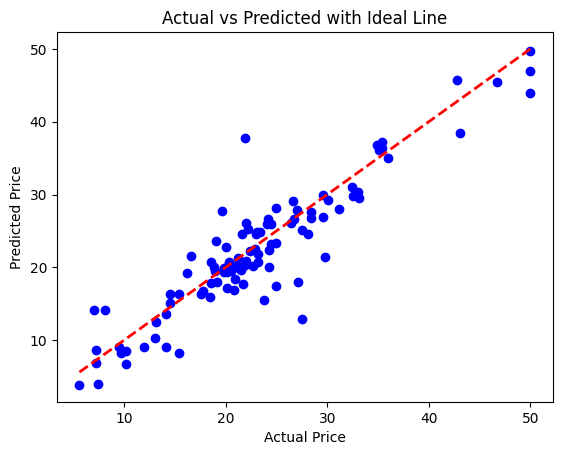

In [28]:
# Points are more closer to the ideal line that means our models working perfectly
import matplotlib.pyplot as plt

plt.scatter(y_test, pred, color='blue')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red',
         linestyle='--',
         linewidth=2)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted with Ideal Line")

plt.show()